In [25]:
import os
from pathlib import Path
from collections import defaultdict
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [7]:
meta= pd.read_csv(r"D:\Education\Cellula\EyeDisease\local\Data\metadata.csv")
meta.sample(5)

,filename,dataset,unified_label,original_label
3114,APTOS_image_01093.png,APTOS2019,Normal,No DR
2224,APTOS_image_2 (42).png,APTOS2019,Diabetic Retinopathy,DR
9808,ODIR_3107_right.jpg,ODIR5K,Normal,N
11406,ODIR_4437_right.jpg,ODIR5K,Diabetic Retinopathy,D
3393,APTOS_image_01652.png,APTOS2019,Normal,No DR


In [8]:
meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 11839 entries, 0 to 11838
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   filename        11839 non-null  str  
 1   dataset         11839 non-null  str  
 2   unified_label   11839 non-null  str  
 3   original_label  11839 non-null  str  
dtypes: str(4)
memory usage: 370.1 KB


In [9]:
meta.dataset.value_counts()

dataset
ODIR5K       7000
APTOS2019    3484
ACRIMA        705
ORIGA         650
Name: count, dtype: int64

In [14]:
meta.unified_label.value_counts()

unified_label
Normal                  4698
Diabetic Retinopathy    4113
Others                  1102
Glaucoma                 930
Cataract                 340
Myopia                   294
AMD                      274
Hypertension              88
Name: count, dtype: int64

In [12]:
missing = meta.isnull().sum()
missing_pct = (missing / len(meta) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
print(missing_df)

                missing  pct
filename              0  0.0
dataset               0  0.0
unified_label         0  0.0
original_label        0  0.0


In [13]:
dup_rows = meta.duplicated().sum()
dup_filenames = meta["filename"].duplicated().sum()
print(f"Duplicate rows: {dup_rows}")
print(f"Duplicate filenames: {dup_filenames}")

Duplicate rows: 0
Duplicate filenames: 0


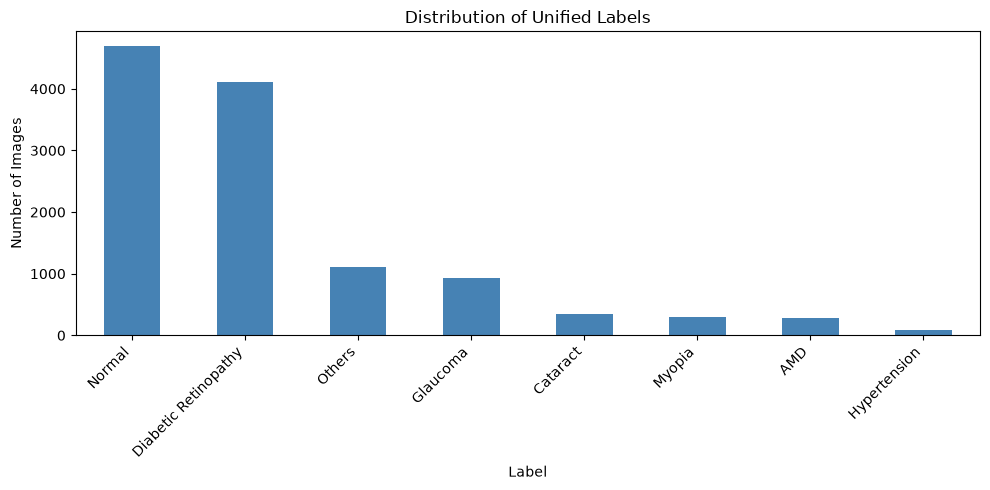

In [16]:
plt.figure(figsize=(10, 5))
meta["unified_label"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribution of Unified Labels")
plt.xlabel("Label")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

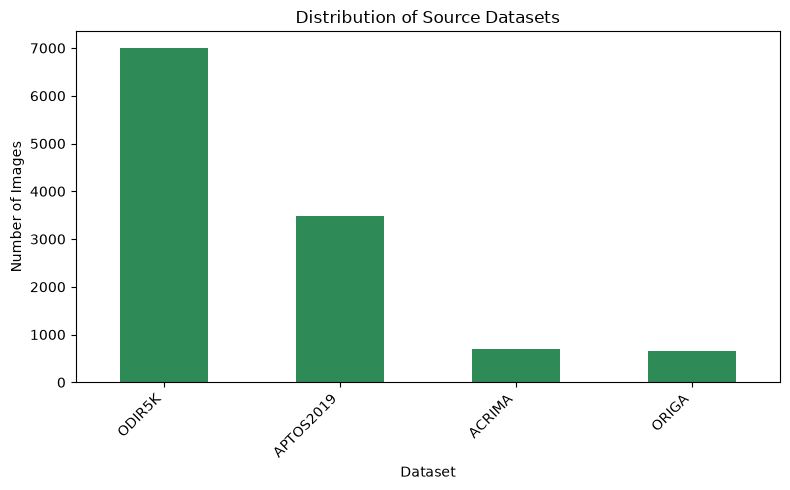

In [17]:
plt.figure(figsize=(8, 5))
meta["dataset"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Distribution of Source Datasets")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
ct = pd.crosstab(meta["dataset"], meta["unified_label"])
print(ct)

unified_label  AMD  Cataract  Diabetic Retinopathy  Glaucoma  Hypertension  \
dataset                                                                      
ACRIMA           0         0                     0       396             0   
APTOS2019        0         0                  1857         0             0   
ODIR5K         274       340                  2256       366            88   
ORIGA            0         0                     0       168             0   

unified_label  Myopia  Normal  Others  
dataset                                
ACRIMA              0     309       0  
APTOS2019           0    1627       0  
ODIR5K            294    2280    1102  
ORIGA               0     482       0  


In [20]:
IMAGES_DIR = Path(r"D:\Education\Cellula\EyeDisease\local\Data\images")

# Get all files in the folder (including subfolders)
all_files = [p for p in IMAGES_DIR.rglob("*") if p.is_file()]

print(f"Total files in images/: {len(all_files)}")

Total files in images/: 11839


Total images to show: 16


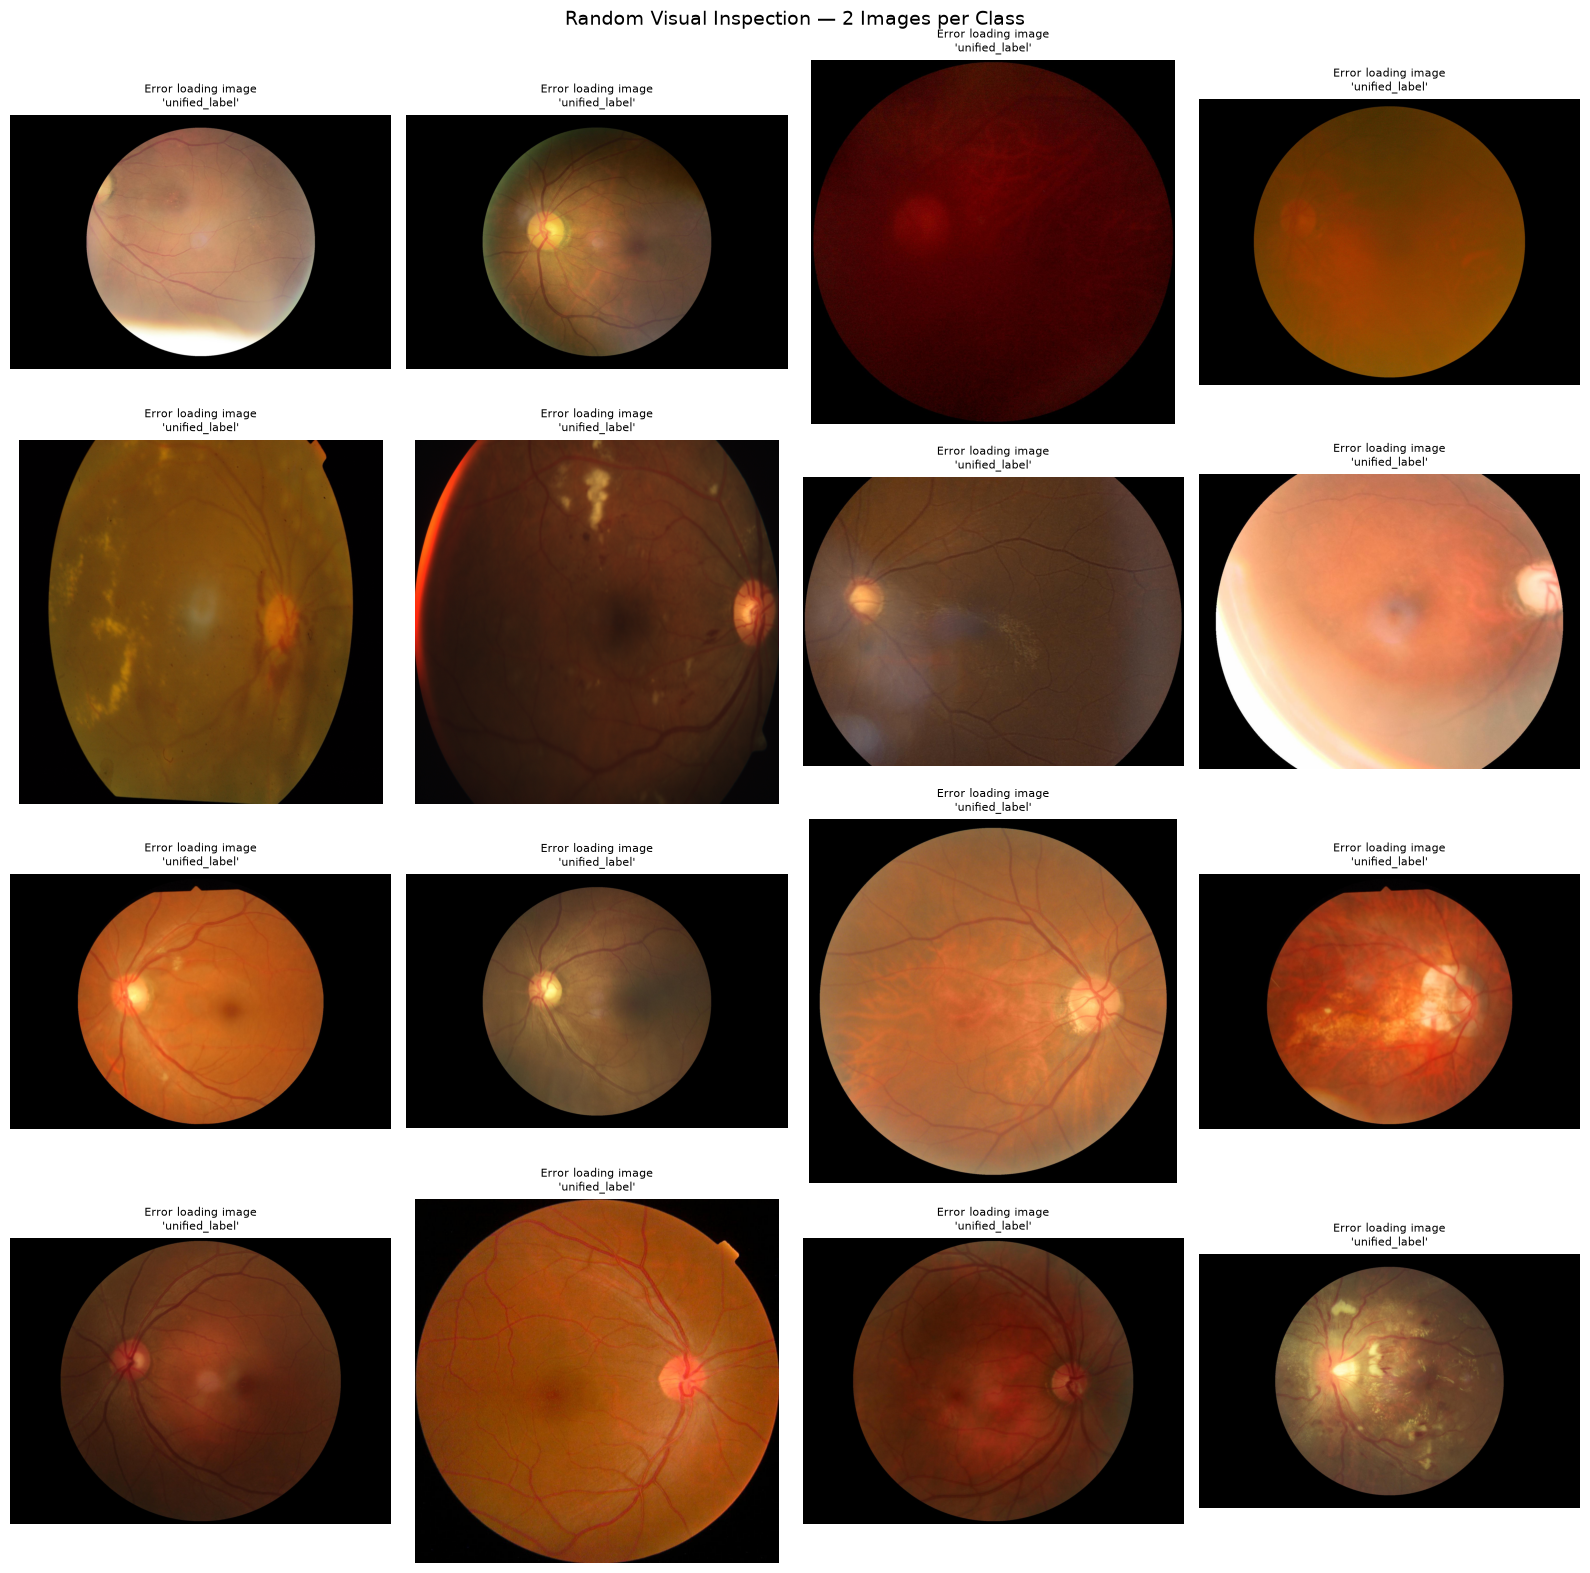

In [ ]:
# Take up to 2 random samples per class
n_per_class = 2

sample_df = (
    meta.groupby("unified_label", group_keys=False)
        .apply(
            lambda x: x.sample(
                n=min(n_per_class, len(x)),
                random_state=42
            ),
            include_groups=False
        )
        .reset_index(drop=True)
)

print(f"Total images to show: {len(sample_df)}")

# Calculate grid size
n = len(sample_df)
cols = 4
rows = max(1, (n + cols - 1) // cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 4, rows * 4)
)

# Make sure axes is always a flat array
axes = axes if hasattr(axes, "flatten") else [axes]
axes = list(axes) if not hasattr(axes, "flatten") else axes.flatten()

# Plot images
for i, (_, row) in enumerate(sample_df.iterrows()):

    try:
        img = Image.open(row["image_path"])

        axes[i].imshow(img)
        axes[i].set_title(
            f"Label: {row['unified_label']}\n"
            f"Dataset: {row['dataset']}\n"
            f"Orig: {row['original_label']}",
            fontsize=9
        )
        axes[i].axis("off")

    except Exception as e:
        axes[i].set_title(f"Error loading image\n{e}", fontsize=8)
        axes[i].axis("off")

# Hide empty subplots
for j in range(len(sample_df), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Random Visual Inspection — 2 Images per Class",
    fontsize=14
)

plt.tight_layout()
plt.show()